In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [132]:
tips = pd.read_csv('content/tips.csv')
ttc = pd.read_csv('content/titanic_train.csv')

(
    ttc.groupby('Pclass')[['PassengerId']].count(),
    ttc.drop(columns=['PassengerId']).groupby('Pclass').sum(numeric_only=True),
    ttc.groupby('Pclass')[['Survived', 'Age']].mean(),
    ttc.groupby(['Sex', 'Pclass'])[['Survived', 'Age']].mean(),
    tips.groupby(by='day', as_index=True)[['tip']].sum(),
)

(        PassengerId
 Pclass             
 1               216
 2               184
 3               491,
         Survived      Age  SibSp  Parch        Fare
 Pclass                                             
 1            136  7111.42     90     77  18177.4125
 2             87  5168.83     74     70   3801.8417
 3            119  8924.92    302    193   6714.6951,
         Survived        Age
 Pclass                     
 1       0.629630  38.233441
 2       0.472826  29.877630
 3       0.242363  25.140620,
                Survived        Age
 Sex    Pclass                     
 female 1       0.968085  34.611765
        2       0.921053  28.722973
        3       0.500000  21.750000
 male   1       0.368852  41.281386
        2       0.157407  30.740707
        3       0.135447  26.507589,
          tip
 day         
 Fri    51.96
 Sat   260.40
 Sun   247.39
 Thur  171.83)

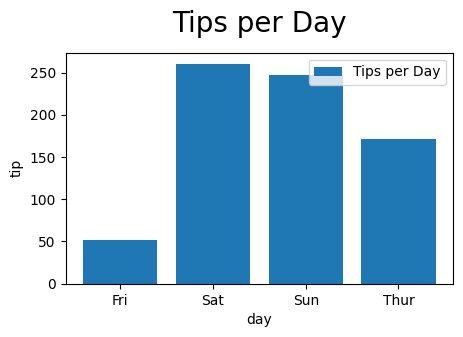

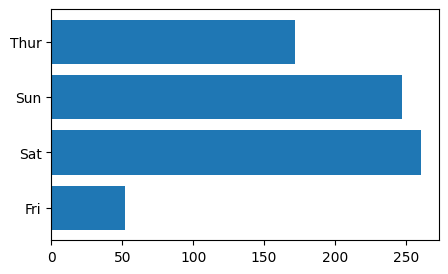

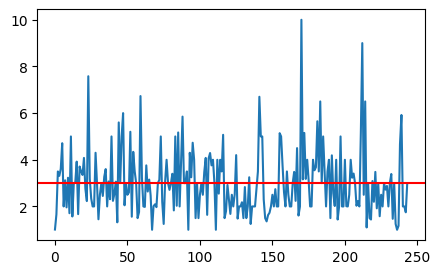

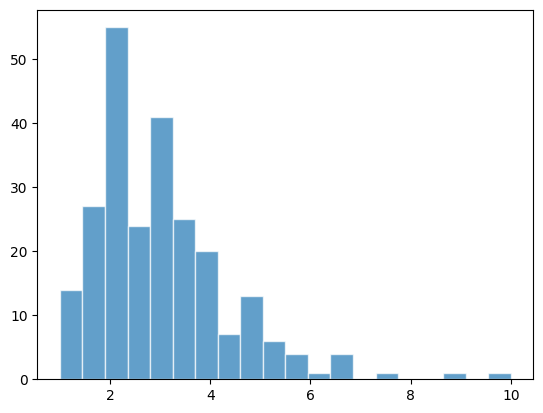

In [133]:
tips_sum = tips.groupby(by='day', as_index=False)[['tip']].sum()
# day별 tip 비교 시각화
plt.figure(figsize=(5,3))
plt.bar(x=tips_sum['day'], height=tips_sum['tip'])
plt.title('Tips per Day', size=20, pad=15)

# 라벨
plt.xlabel('day')
plt.ylabel('tip')

# 범례(legend) 추가
plt.legend(['Tips per Day'])
plt.show()

#plt.bar() 대신 plt.barh() 함수를 사용해 가로 막대그래프를 표시할 수 있다.
plt.figure(figsize=(5,3))
plt.barh(tips_sum['day'], tips_sum['tip'])
plt.show()

# tip 변화 추이 시각화
tips_mean = tips['tip'].mean()

plt.figure(figsize=(5,3))

# tip 변화 추이 시각화(선그래프)
plt.plot(tips['tip'])               # 'tip'열의 데이터를 순서대로 선 그래프로 그림

# 평균 팁을 나타내는 수평선 그리기
plt.axhline(tips_mean, color='r')   # 평 균 팁 값에 해당하는 위치에 빨간색 수평선을 그림
plt.show()

# tip 분포 시각화
plt.hist(tips['tip'], bins=20, alpha=0.7, edgecolor='w')
plt.show()



In [134]:
(
    tips.groupby('day')['tip'].agg(['sum', 'mean','max', 'min']),
    tips.groupby(['day', 'smoker']).agg(sum_bill = ('total_bill', 'sum'), mean_tip = ('tip', 'mean')),
    tips.groupby('day')[['total_bill','tip']].agg(['sum', 'mean']),
)

(         sum      mean    max   min
 day                                
 Fri    51.96  2.734737   4.73  1.00
 Sat   260.40  2.993103  10.00  1.00
 Sun   247.39  3.255132   6.50  1.01
 Thur  171.83  2.771452   6.70  1.25,
              sum_bill  mean_tip
 day  smoker                    
 Fri  No         73.68  2.812500
      Yes       252.20  2.714000
 Sat  No        884.78  3.102889
      Yes       893.62  2.875476
 Sun  No       1168.88  3.167895
      Yes       458.28  3.516842
 Thur No        770.09  2.673778
      Yes       326.24  3.030000,
      total_bill                tip          
             sum       mean     sum      mean
 day                                         
 Fri      325.88  17.151579   51.96  2.734737
 Sat     1778.40  20.441379  260.40  2.993103
 Sun     1627.16  21.410000  247.39  3.255132
 Thur    1096.33  17.682742  171.83  2.771452)

In [135]:
ga = pd.read_csv('content/Graduate_apply.csv')

(
    ga.groupby('rank').agg(m_gre=('gre', 'median'), mean_gpa=('gpa', 'mean')),
    ga.groupby(['rank', 'admit'])[['gpa']].mean(),
    ga[ga['admit'] == 1].groupby('rank')[['rank']].count(),
    ga.groupby(by='rank', as_index=False)[['admit']].mean()
)

(      m_gre  mean_gpa
 rank                 
 1     600.0  3.453115
 2     600.0  3.361656
 3     580.0  3.432893
 4     560.0  3.318358,
                  gpa
 rank admit          
 1    0      3.345714
      1      3.544242
 2    0      3.316598
      1      3.442593
 3    0      3.402258
      1      3.534643
 4    0      3.291455
      1      3.441667,
       rank
 rank      
 1       33
 2       54
 3       28
 4       12,
    rank     admit
 0     1  0.540984
 1     2  0.357616
 2     3  0.231405
 3     4  0.179104)

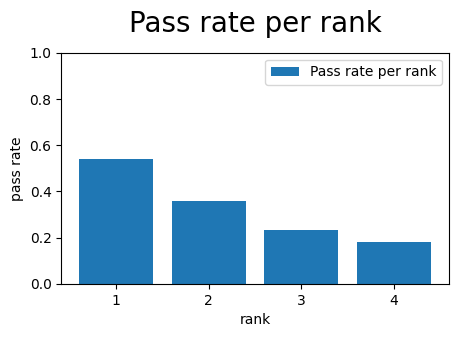

In [136]:
pass_rate = ga.groupby(by="rank", as_index=False)[["admit"]].mean()

plt.figure(figsize=(5, 3))
plt.bar(x=pass_rate["rank"], height=pass_rate["admit"])
plt.title("Pass rate per rank", size=20, pad=15)

# 라벨
plt.xticks(pass_rate["rank"])
plt.xlabel("rank")
plt.ylabel("pass rate")
plt.ylim(0, 1)

# 범례(legend) 추가
plt.legend(["Pass rate per rank"])
plt.show()


In [137]:
tips = pd.read_csv('content/tips(2).csv')

tips.rename(columns={
    'total_bill_amount': 'total_bill',
    'male_female': 'sex',
    'smoke_yes_no': 'smoker',
    'week_name': 'day',
    'dinner_lunch': 'time',
}, inplace=True),
tips.insert(5,'final_amt', tips['total_bill'] + tips['tip']),
tips.insert(1, 'div_tb', tips['total_bill']/tips['size'])
tips['holiday'] = tips['day'].isin(['Sat', 'Sun']).astype(int)
tips.drop('final_amt', axis=1, inplace=True)
tips['tip_grp'] = pd.cut(tips['tip'], bins=[-np.inf, 2.0, 2.9, 3.5625, 10], labels=['a', 'b', 'c', 'd'])
tips['total_bill_grp'] = pd.cut(tips['total_bill'], bins=[
    -np.inf,
    13.347500,
    17.795000,
    24.127500,
    np.inf
], labels=['a', 'b', 'c', 'd'])
(
    tips.head(1),
    tips['day'].unique(),
    tips['holiday'].value_counts(),
    tips['smoker'].map({'Yes': 1, 'No':0}).value_counts(),
    tips['time'].replace({'Lunch': 1, 'Dinner':0}).value_counts(),
    tips['tip_grp'].value_counts(),
    tips['total_bill_grp'].value_counts(),
)

(   total_bill  div_tb   tip     sex smoker  day    time  size  holiday  \
 0       16.99   8.495  1.01  Female     No  Sun  Dinner     2        1   
 
   tip_grp total_bill_grp  
 0       a              b  ,
 <ArrowStringArray>
 ['Sun', 'Sat', 'Thur', 'Fri']
 Length: 4, dtype: str,
 holiday
 1    163
 0     81
 Name: count, dtype: int64,
 smoker
 0    151
 1     93
 Name: count, dtype: int64,
 time
 0    176
 1     68
 Name: count, dtype: int64,
 tip_grp
 a    78
 c    61
 d    61
 b    44
 Name: count, dtype: int64,
 total_bill_grp
 a    61
 b    61
 c    61
 d    61
 Name: count, dtype: int64)

In [138]:
ttc.insert(1,'Family', ttc['SibSp'] + ttc['Parch'])

(
    ttc.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1).head(1),
    ttc.rename(columns={'Sex':'Male'})['Male'].map({'male':1,'female':0}).value_counts(),
    
)

(   Family  Survived  Pclass   Sex   Age  SibSp  Parch  Fare Embarked
 0       1         0       3  male  22.0      1      0  7.25        S,
 Male
 1    577
 0    314
 Name: count, dtype: int64)

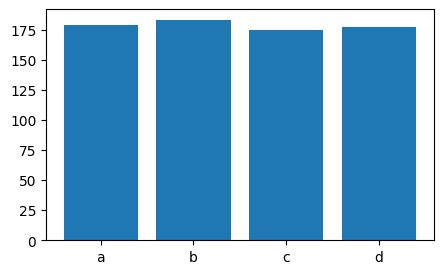

In [139]:
a,b,c = ttc['Age'].describe()[['25%', '50%', '75%']]

ttc['AgeGrp'] = pd.cut(ttc['Age'], bins=[-np.inf, a,b,c, np.inf], labels=list('abcd'))

plt.figure(figsize=(5, 3))
tmp = ttc.groupby('AgeGrp').size().reset_index(name='count')
plt.bar(height=tmp['count'], x=tmp['AgeGrp'])

plt.show()

- 결측치는 어떻게 처리해야 될까? -> 비율에 따라 다르게
    - **결측치가 데이터의 5% 미만** : 일부분에만 결측치가 존재하므로 결측치가 있는 행을 삭제하는 것이 적절.이렇게 하면 데이터 손실이 최소화되며, 분석의 신뢰성에 큰 영향을 미치지 않음.
    - **결측치가 데이터의 5%에서 20% 사이** : 결측치가 꽤 많은 상태이므로 삭제보다는 대체하는 방법이 더 적합. 평균, 중간값, 최빈값 등을 사용해 대체하거나, 필요에 따라 모델 기반 처리도 고려.
    - **결측치가 데이터의 20% 이상** : 결측치가 너무 많은 상태이므로 결측치가 있는 열 전체를 제거하는 것이 권장되지만, 데이터 손실이 크기 때문에 신중한 판단이 필요. 특히 데이터셋이 작거나 해당 변수가 중요한 역할을 할 때는 모델 기반 대체나 예측 모델을 통해 결측치를 보완하는 것이 더 적합할 수 있음. 따라서, 결측치가 20% 이상이라도 변수의 중요성, 분석 목적, 데이터 양을 종합적으로 고려해 열을 제거할지, 대체할지를 결정하는 것이 중요.


- 다만, 이러한 기준은 이론적인 가이드라인일 뿐, 절대적인 규칙은 아니다. 데이터의 특성, 분석 목적, 실무 환경에 따라 다양한 조정이 필요할 수 있다.


In [166]:
air = pd.read_csv('content/airquality.csv')

(
    air['Ozone'].isnull().sum(),
    air.dropna(subset='Ozone').head(1),
    air.dropna(axis=1).head(1),
    air['Ozone'].interpolate(method='linear').value_counts().head(3),
    pd.get_dummies(tips['day']).head(1)
)

(np.int64(37),
    Ozone  Solar.R  Wind  Temp  Month  Day
 0   41.0    190.0   7.4    67      5    1,
    Wind  Temp  Month  Day
 0   7.4    67      5    1,
 Ozone
 23.0    7
 18.0    4
 16.0    4
 Name: count, dtype: int64,
      Fri    Sat   Sun   Thur
 0  False  False  True  False)

## 6.2.가변수(Dummy Variable) 만들기

- 가변수는 일정하게 정해진 범위의 값을 갖는 데이터(범주형 데이터)를 독립된 열로 변환한 것이다.
- 특히 범주형 문자열 데이터는 머신러닝 알고리즘에 사용하려면 숫자로 변환해야 한다.
- 가변수를 만드는 과정을 **One-Hot-Encoding** 이라고 부르기도 한다.
- **get_dummies()** 함수를 사용해서 가변수를 쉽게 만들 수 있다.

**[참고] 다중공선성 문제**
- 통계학의 회귀분석에서 독립변수들 간에 강한 상관관계가 나타나는 문제이다.
- 독립변수들 간에 정확한 선형관계가 존재하는 **완전공선성**의 경우와 독립변수들 간에 높은 선형관계가 존재하는 **다중공선성**으로 구분하기도 한다.
- 이는 회귀분석의 전제 가정을 위배하는 것이므로 적절한 회구분석을 위해 해결해야 하는 문제가 된다.(위키백과)

In [186]:
dttc = ttc.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

dttc['Age'] = dttc['Age'].fillna(dttc['Age'].mean())
dttc['Embarked'] = dttc['Embarked'].fillna('S')

(
    dttc['Age'].isnull().sum(),
    dttc['Embarked'].isnull().sum(),
    pd.get_dummies(dttc, columns=['Pclass', 'Sex', 'Embarked'], drop_first=True)
)


(np.int64(0),
 np.int64(0),
      Family  Survived        Age  SibSp  Parch     Fare AgeGrp  Pclass_2  \
 0         1         0  22.000000      1      0   7.2500      b     False   
 1         1         1  38.000000      1      0  71.2833      c     False   
 2         0         1  26.000000      0      0   7.9250      b     False   
 3         1         1  35.000000      1      0  53.1000      c     False   
 4         0         0  35.000000      0      0   8.0500      c     False   
 ..      ...       ...        ...    ...    ...      ...    ...       ...   
 886       0         0  27.000000      0      0  13.0000      b      True   
 887       0         1  19.000000      0      0  30.0000      a     False   
 888       3         0  29.699118      1      2  23.4500    NaN     False   
 889       0         1  26.000000      0      0  30.0000      b     False   
 890       0         0  32.000000      0      0   7.7500      c     False   
 
      Pclass_3  Sex_male  Embarked_Q  Embarked

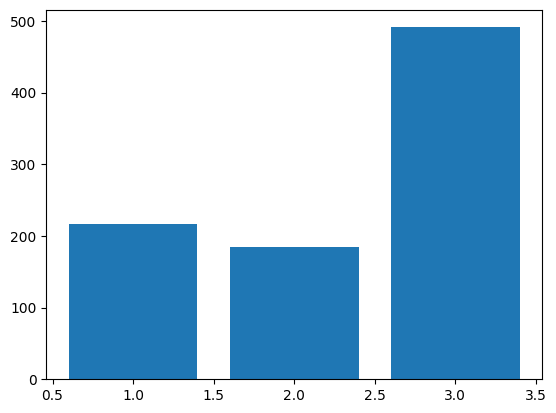

In [187]:
tmp = dttc.groupby('Pclass', as_index=False).agg(Count=('Survived', 'count'))

plt.bar(x=tmp['Pclass'], height=tmp['Count'])

plt.show()

In [ ]:
(
    air[['Ozone', 'Solar.R']].ffill().info(),
    
)

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    153 non-null    float64
 1   Solar.R  153 non-null    float64
dtypes: float64(2)
memory usage: 2.5 KB


(None,)

In [253]:
pop01 = pd.read_csv("content/seoul_pop_01.csv", index_col="year").reset_index(drop=False)
pop02 = pd.read_csv("content/seoul_pop_02.csv", index_col="year").reset_index(drop=False)
pop03 = pd.read_csv("content/seoul_pop_03.csv", index_col="year").reset_index(drop=False)

pop = pd.merge(pd.merge(pop01, pop02, on="year"), pop03, on="year")

(
    pd.concat([pop01, pop02, pop03], join="outer", axis=1)[["f_male", "f_female"]]
    .bfill()
    .info(),
    pop.assign(
        k_total=lambda x: x["k_male"] + x["k_female"],
        f_total=lambda x: x["f_male"] + x["f_female"],
        male=lambda x: x["k_male"] + x["f_male"],
        female=lambda x: x["k_female"] + x["f_female"],
        total=lambda x: x["k_total"] + x["f_total"],
    )[[ 'year', 'total', 'male', 'female']].head(10),
)


<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   f_male    38 non-null     float64
 1   f_female  38 non-null     float64
dtypes: float64(2)
memory usage: 804.0 bytes


(None,
    year  total  male  female
 0  1985   8364  4167    4197
 1  1986   9799  4906    4893
 2  1987   9990  5006    4984
 3  1988  10286  5161    5125
 4  1989  10577  5311    5266
 5  1990  10612  5326    5286
 6  1991  10905  5486    5419
 7  1992  10970  5519    5451
 8  1993  10926  5497    5429
 9  1994  10800  5430    5370)